Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset size: 2874
All points shape: (2874, 50, 3)

GLOBAL COORDINATE STATS



,mean,std,min,max,q01,q99
X,-0.021655,0.157390,-0.48966,0.48905,-0.362861,0.34415
Y,0.009594,0.185506,-0.49936,0.49890,-0.437331,0.40804
Z,0.001080,0.166942,-0.48505,0.48680,-0.394900,0.39373



PER-SHAPE STATS (HEAD)



,shape_name,label,mean_radius,std_radius,max_radius,bbox_volume,dx,dy,dz,nn_mean,nn_std
0,a1708ad923f3b51abbf3143b1cb6076a,0,0.177847,0.078311,0.331095,0.050604,0.61915,0.15220,0.53700,0.033599,0.024082
1,b72804a8bd3dbbaca8607f540cc62ba,0,0.192006,0.102404,0.385602,0.030797,0.74688,0.15626,0.26388,0.030493,0.016959
2,8add45a11c9fcb446eb5821e78d8898a,0,0.210801,0.088015,0.398775,0.038893,0.72472,0.19460,0.27578,0.045534,0.025085
3,ed7e1a38fe33830b87697d3904b168b,0,0.223718,0.081436,0.360355,0.077330,0.70201,0.17314,0.63622,0.038538,0.033916
4,de29a1335c332a5ef7bc9a344bb7bae5,0,0.177191,0.090652,0.330211,0.029480,0.56028,0.09598,0.54821,0.035041,0.016149



PER-CLASS GEOMETRY STATS



,mean_radius,std_radius,max_radius,bbox_volume,dx,dy,dz,nn_mean,nn_std
label,,,,,,,,,
0,0.189011,0.088509,0.370139,0.045826,0.645137,0.142573,0.507887,0.036393,0.020868
1,0.269219,0.092539,0.444265,0.083295,0.225209,0.626819,0.625034,0.067032,0.033775
2,0.269295,0.059311,0.374567,0.113415,0.640029,0.332409,0.545019,0.060006,0.033087
3,0.266579,0.097658,0.441251,0.069317,0.833796,0.246848,0.338859,0.062283,0.030126
4,0.264692,0.097529,0.457581,0.125630,0.435541,0.706458,0.422688,0.061394,0.037053
5,0.300983,0.055108,0.410550,0.097724,0.252624,0.661294,0.600769,0.052343,0.028212
6,0.263119,0.122184,0.467559,0.011738,0.047611,0.887426,0.276756,0.032501,0.017164
7,0.237664,0.129213,0.475729,0.007436,0.146929,0.897645,0.059356,0.030178,0.015478
8,0.313744,0.090759,0.441030,0.084605,0.385771,0.737886,0.317285,0.046127,0.028522



CLASS BALANCE



0     341
1      14
2      11
3     158
4     704
5      14
6     159
7      80
8     286
9      83
10     51
11     38
12     44
13     12
14     31
15    848
Name: count, dtype: int64

C:\Users\romai\AppData\Local\Temp\ipykernel_72020\1043614501.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([XYZ[:,0], XYZ[:,1], XYZ[:,2]], labels=["X", "Y", "Z"])


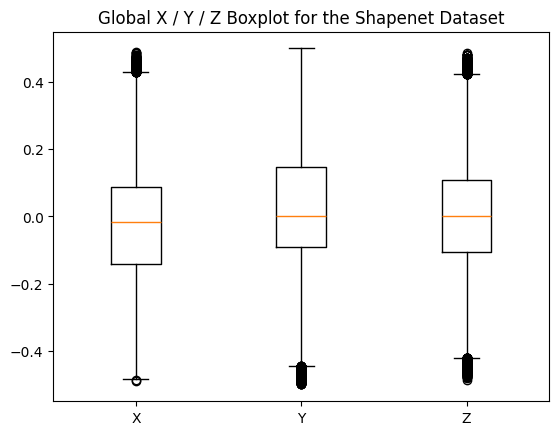

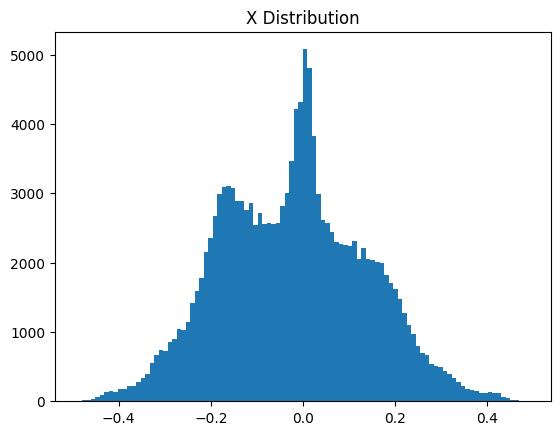

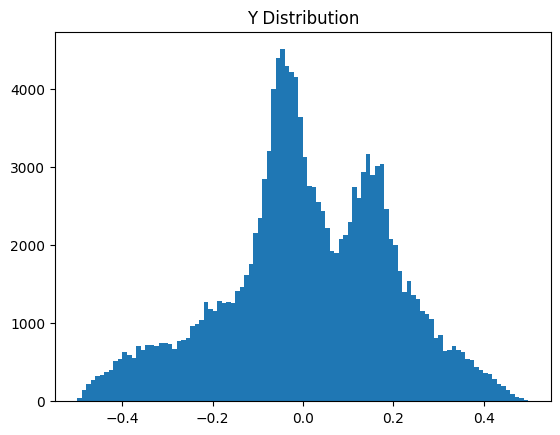

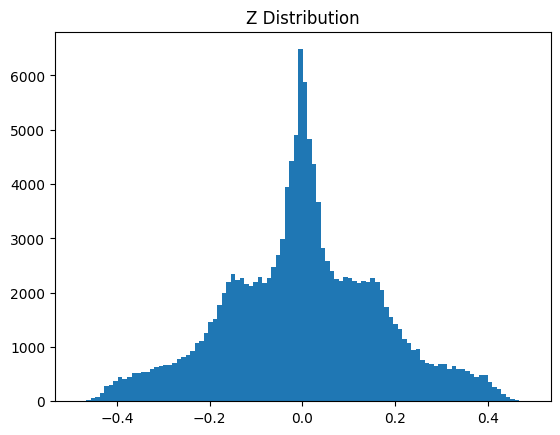

<Figure size 640x480 with 0 Axes>

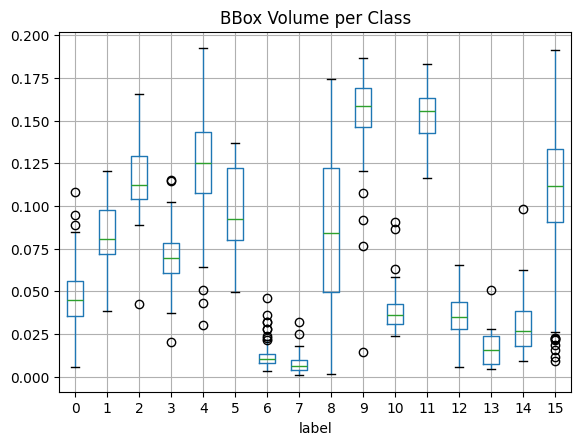

<Figure size 640x480 with 0 Axes>

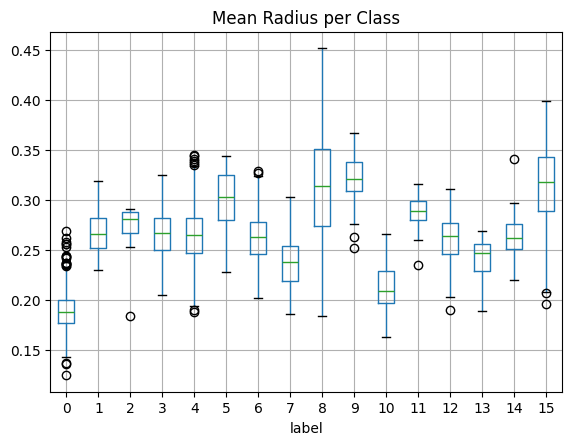

<Figure size 640x480 with 0 Axes>

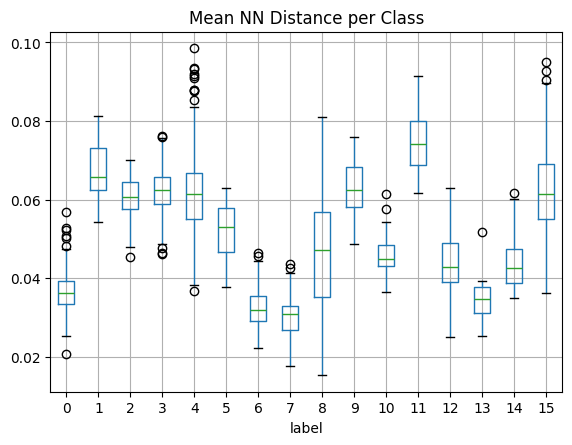

In [ ]:
import os, os.path as osp
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

from UTILS.shapenet_dataset import ShapenetDataset

# =========================
# USER SETTINGS (EDIT)
# =========================
ROOT = os.getcwd()
data_folder = "shapenetcore_partanno_segmentation_benchmark_v0"
class_choice = [
    "Airplane",
    "Bag",
    "Cap",
    "Car",
    "Chair",
    "Earphone",
    "Guitar",
    "Knife",
    "Lamp",
    "Laptop",
    "Motorbike",
    "Mug",
    "Pistol",
    "Rocket",
    "Skateboard",
    "Table"
]
npoints = 50
batch_size = 16

# =========================
# LOAD DATASET
# =========================
dataset_root = osp.join(str(ROOT), data_folder)

ds = ShapenetDataset(
    dataset_root,
    class_choice=class_choice,
    npoints=npoints,
    split="test",
    classification=True,
    normalize=False
)

dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

print("Dataset size:", len(ds))

# =========================
# COLLECT ALL POINTS
# =========================
all_points = []
all_labels = []
all_names = []

for batch in dl:
    pts = batch[0].numpy()
    lbl = batch[1].numpy()
    all_points.append(pts)
    all_labels.append(lbl)

all_points = np.concatenate(all_points, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_names = [osp.splitext(osp.basename(seg))[0] for *_, seg, _ in ds.datapath]


print("All points shape:", all_points.shape)

# =========================
# GLOBAL COORDINATE STATS
# =========================
XYZ = all_points.reshape(-1, 3)

global_df = pd.DataFrame({
    "mean": XYZ.mean(axis=0),
    "std":  XYZ.std(axis=0),
    "min":  XYZ.min(axis=0),
    "max":  XYZ.max(axis=0),
    "q01":  np.quantile(XYZ, 0.01, axis=0),
    "q99":  np.quantile(XYZ, 0.99, axis=0),
}, index=["X", "Y", "Z"])

print("\nGLOBAL COORDINATE STATS\n")
display(global_df)

# =========================
# PER-SHAPE GEOMETRY STATS
# =========================
shape_rows = []

for i in range(len(all_points)):
    P = all_points[i]

    norms = np.linalg.norm(P, axis=1)
    min_xyz = P.min(axis=0)
    max_xyz = P.max(axis=0)
    dims = max_xyz - min_xyz
    bbox_volume = dims[0] * dims[1] * dims[2]

    nbrs = NearestNeighbors(n_neighbors=2).fit(P)
    dists, _ = nbrs.kneighbors(P)

    shape_rows.append([
        all_names[i],
        int(all_labels[i].item()),
        norms.mean(),
        norms.std(),
        norms.max(),
        bbox_volume,
        dims[0], dims[1], dims[2],
        dists[:,1].mean(),
        dists[:,1].std()
    ])

shape_df = pd.DataFrame(shape_rows, columns=[
    "shape_name", "label",
    "mean_radius", "std_radius", "max_radius",
    "bbox_volume", "dx", "dy", "dz",
    "nn_mean", "nn_std"
])

print("\nPER-SHAPE STATS (HEAD)\n")
display(shape_df.head())

# =========================
# PER-CLASS STATS
# =========================
class_df = shape_df.drop(columns=["shape_name"]).groupby("label").mean()

print("\nPER-CLASS GEOMETRY STATS\n")
display(class_df)

# =========================
# CLASS BALANCE
# =========================
class_balance = pd.Series(all_labels.ravel()).value_counts().sort_index()
print("\nCLASS BALANCE\n")
display(class_balance)

# =========================
# PLOTS
# =========================

plt.figure()
plt.boxplot([XYZ[:,0], XYZ[:,1], XYZ[:,2]], labels=["X", "Y", "Z"])
plt.title("Global X / Y / Z Boxplot for the Shapenet Dataset")
plt.show()

plt.figure()
plt.hist(XYZ[:,0], bins=100)
plt.title("X Distribution")
plt.show()

plt.figure()
plt.hist(XYZ[:,1], bins=100)
plt.title("Y Distribution")
plt.show()

plt.figure()
plt.hist(XYZ[:,2], bins=100)
plt.title("Z Distribution")
plt.show()

plt.figure()
shape_df.boxplot(column="bbox_volume", by="label")
plt.title("BBox Volume per Class")
plt.suptitle("")
plt.show()

plt.figure()
shape_df.boxplot(column="mean_radius", by="label")
plt.title("Mean Radius per Class")
plt.suptitle("")
plt.show()

plt.figure()
shape_df.boxplot(column="nn_mean", by="label")
plt.title("Mean NN Distance per Class")
plt.suptitle("")
plt.show()


Scanning K with BIC...


100%|██████████| 8/8 [01:20<00:00, 10.06s/it]


✅ Optimal number of GMM components K = 61


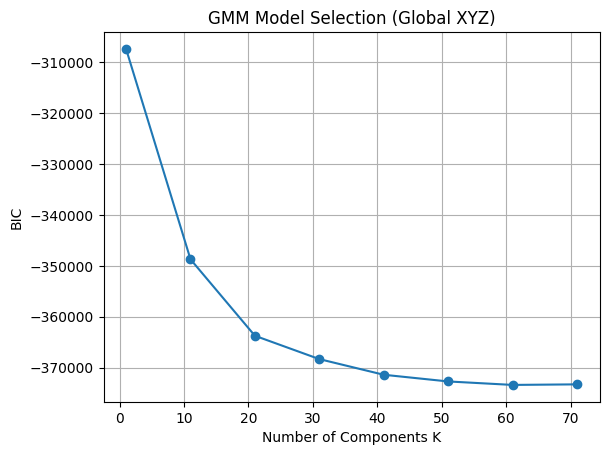

Fitting final GMM...
✅ GMM converged: True
Mixture weights: [0.0168 0.031  0.0147 0.0222 0.0174 0.0156 0.0185 0.019  0.0101 0.0094
 0.0113 0.0157 0.0145 0.0284 0.0267 0.0195 0.0114 0.0196 0.0079 0.0125
 0.0248 0.0209 0.0095 0.0095 0.0136 0.0148 0.0114 0.0131 0.0147 0.0233
 0.0246 0.0221 0.0219 0.015  0.0103 0.0115 0.0196 0.0193 0.0212 0.0136
 0.0198 0.0187 0.0122 0.0149 0.0145 0.0163 0.0168 0.023  0.0117 0.0105
 0.0143 0.0149 0.0282 0.0131 0.0104 0.0112 0.0092 0.0223 0.0137 0.0088
 0.0186]


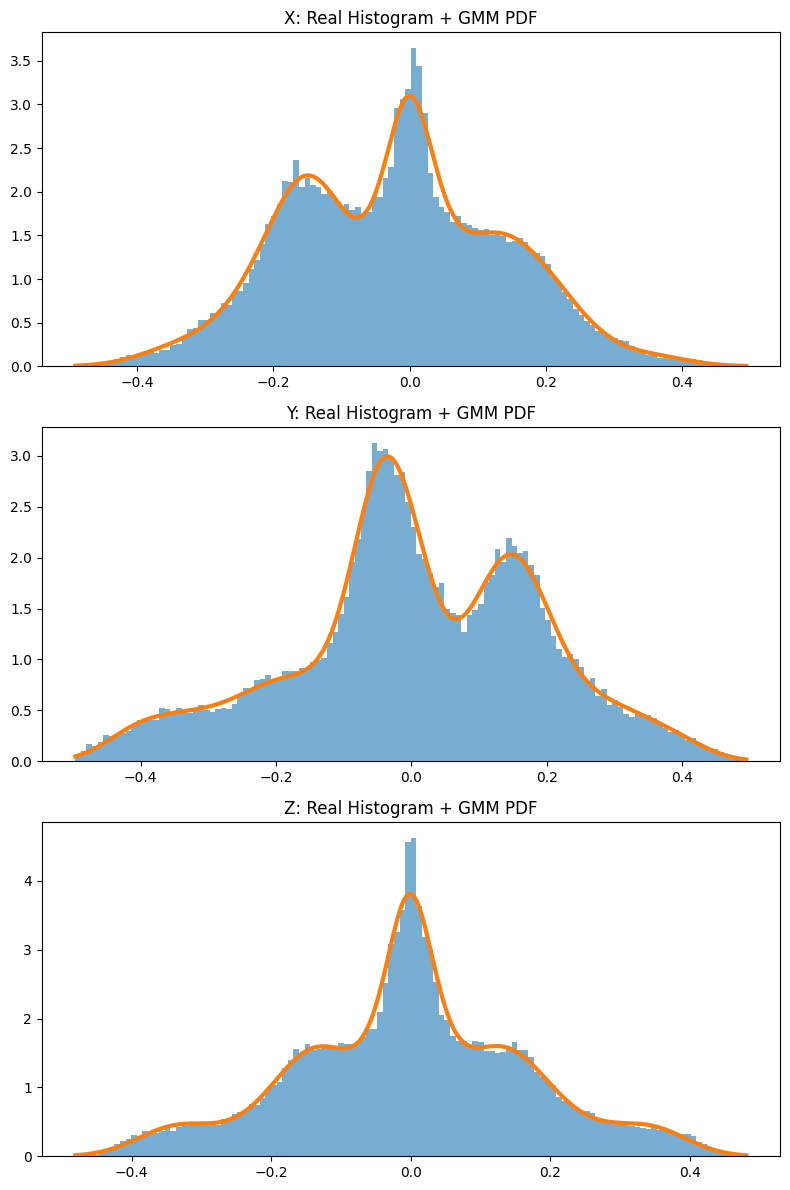

In [ ]:
# =========================
# GLOBAL 3D GMM: FIT + SAMPLE + PLOT (SINGLE CELL WITH TQDM)
# =========================

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm   # ✅ progress bar

# --- 1. Model selection via BIC ---
Ks = range(1, 80, 10)
bics = []

print("Scanning K with BIC...")
for k in tqdm(Ks):
    gmm_k = GaussianMixture(
        n_components=k,
        covariance_type="full",
        max_iter=300,
        n_init=3,
        random_state=0
    )
    gmm_k.fit(XYZ)
    bics.append(gmm_k.bic(XYZ))

K_opt = Ks[np.argmin(bics)]
print(f"\n✅ Optimal number of GMM components K = {K_opt}")

plt.figure()
plt.plot(Ks, bics, marker="o")
plt.xlabel("Number of Components K")
plt.ylabel("BIC")
plt.title("GMM Model Selection (Global XYZ)")
plt.grid(True)
plt.show()

# --- 2. Fit final GMM ---
print("Fitting final GMM...")
gmm = GaussianMixture(
    n_components=K_opt,
    covariance_type="full",
    max_iter=500,
    n_init=5,
    random_state=0
)
gmm.fit(XYZ)

print("✅ GMM converged:", gmm.converged_)
print("Mixture weights:", np.round(gmm.weights_, 4))

from scipy.stats import norm

# --- 4. Plot: Real hist + GMM PDF curve ---
labels = ["X", "Y", "Z"]

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

for i in range(3):
    ax = axs[i]

    # Histogram (real data)
    ax.hist(XYZ[:, i], bins=120, density=True, alpha=0.6)
    
    # Build GMM marginal PDF for this dimension
    x_min, x_max = XYZ[:, i].min(), XYZ[:, i].max()
    x_grid = np.linspace(x_min, x_max, 1000)

    pdf = np.zeros_like(x_grid)
    for k in range(gmm.n_components):
        mean_k = gmm.means_[k, i]
        var_k = gmm.covariances_[k][i, i]
        weight_k = gmm.weights_[k]
        pdf += weight_k * norm.pdf(x_grid, mean_k, np.sqrt(var_k))

    # Plot GMM curve
    ax.plot(x_grid, pdf, linewidth=3)

    ax.set_title(f"{labels[i]}: Real Histogram + GMM PDF")

plt.tight_layout()
plt.show()


Scanning K with BIC...


100%|██████████| 10/10 [02:23<00:00, 14.33s/it]


✅ Optimal number of GMM components K = 48


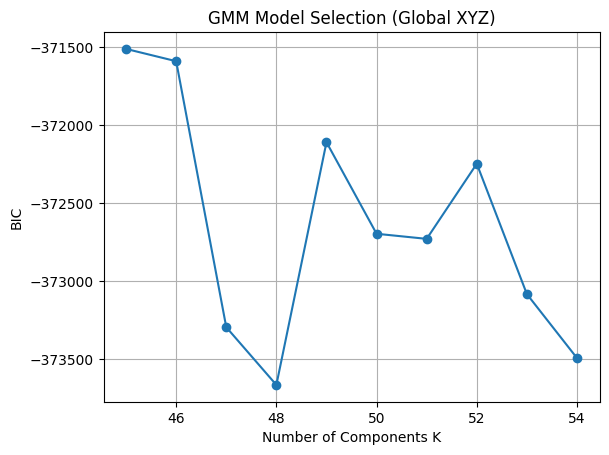

Fitting final GMM...
✅ GMM converged: True
Mixture weights: [0.0163 0.03   0.0344 0.0237 0.0126 0.015  0.017  0.0329 0.0091 0.0223
 0.0343 0.017  0.028  0.0147 0.0128 0.024  0.0193 0.0272 0.0263 0.0139
 0.0191 0.018  0.0114 0.0118 0.0136 0.0168 0.0172 0.0117 0.0363 0.0221
 0.026  0.016  0.0349 0.0246 0.0278 0.0264 0.0282 0.0217 0.0256 0.0126
 0.0254 0.0157 0.0169 0.0163 0.0127 0.0209 0.0226 0.0167]


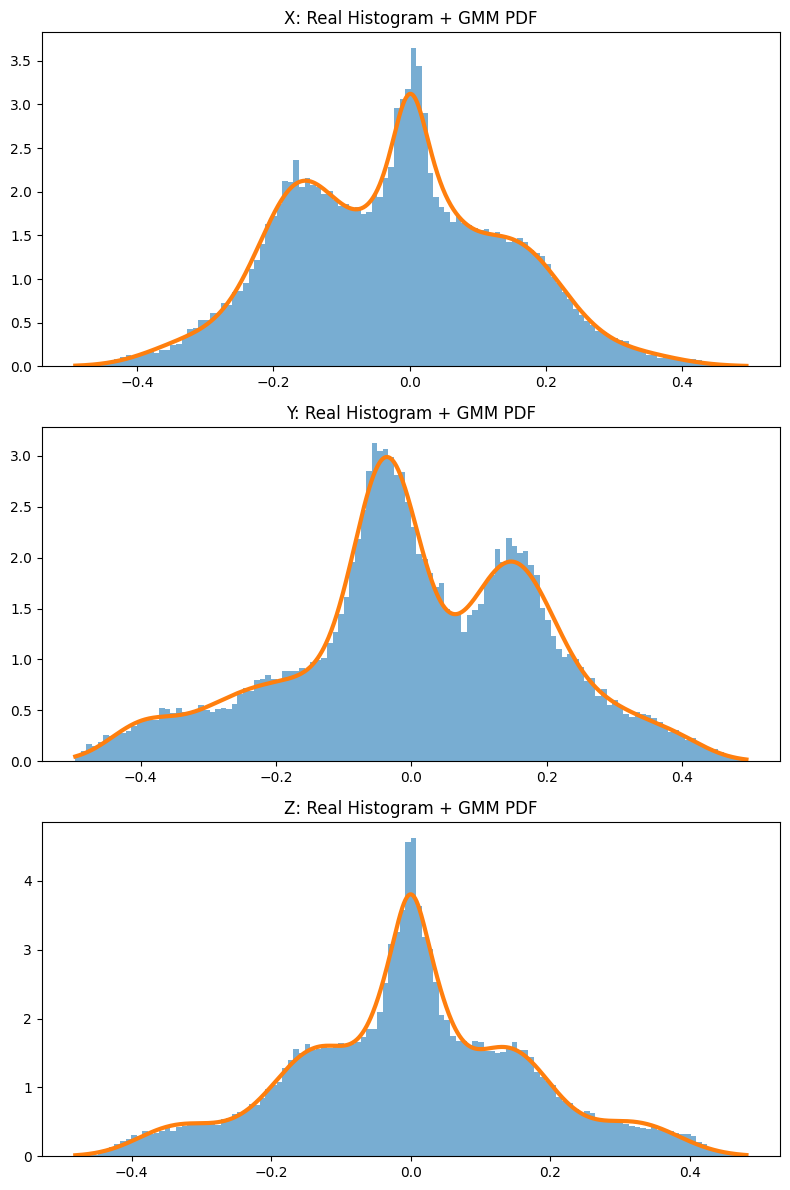

In [ ]:
# =========================
# GLOBAL 3D GMM: FIT + SAMPLE + PLOT (SINGLE CELL WITH TQDM)
# =========================

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm   # ✅ progress bar

# --- 1. Model selection via BIC ---
Ks = range(45, 55)
bics = []

print("Scanning K with BIC...")
for k in tqdm(Ks):
    gmm_k = GaussianMixture(
        n_components=k,
        covariance_type="full",
        max_iter=300,
        n_init=3,
        random_state=0
    )
    gmm_k.fit(XYZ)
    bics.append(gmm_k.bic(XYZ))

K_opt = Ks[np.argmin(bics)]
print(f"\n✅ Optimal number of GMM components K = {K_opt}")

plt.figure()
plt.plot(Ks, bics, marker="o")
plt.xlabel("Number of Components K")
plt.ylabel("BIC")
plt.title("GMM Model Selection (Global XYZ)")
plt.grid(True)
plt.show()

# --- 2. Fit final GMM ---
print("Fitting final GMM...")
gmm = GaussianMixture(
    n_components=K_opt,
    covariance_type="full",
    max_iter=500,
    n_init=5,
    random_state=0
)
gmm.fit(XYZ)

print("✅ GMM converged:", gmm.converged_)
print("Mixture weights:", np.round(gmm.weights_, 4))
from scipy.stats import norm

# --- 4. Plot: Real hist + GMM PDF curve ---
labels = ["X", "Y", "Z"]

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

for i in range(3):
    ax = axs[i]

    # Histogram (real data)
    ax.hist(XYZ[:, i], bins=120, density=True, alpha=0.6)
    
    # Build GMM marginal PDF for this dimension
    x_min, x_max = XYZ[:, i].min(), XYZ[:, i].max()
    x_grid = np.linspace(x_min, x_max, 1000)

    pdf = np.zeros_like(x_grid)
    for k in range(gmm.n_components):
        mean_k = gmm.means_[k, i]
        var_k = gmm.covariances_[k][i, i]
        weight_k = gmm.weights_[k]
        pdf += weight_k * norm.pdf(x_grid, mean_k, np.sqrt(var_k))

    # Plot GMM curve
    ax.plot(x_grid, pdf, linewidth=3)

    ax.set_title(f"{labels[i]}: Real Histogram + GMM PDF")

plt.tight_layout()
plt.show()


In [ ]:
# --- 5. Sanity check: vraie covariance vs covariance GMM analytique ---

# Moyenne globale GMM
mu_global = np.sum(gmm.weights_[:, None] * gmm.means_, axis=0)

# Covariance globale GMM
cov_gmm = np.zeros((3, 3))

for k in range(gmm.n_components):
    wk = gmm.weights_[k]
    muk = gmm.means_[k]
    Sigmak = gmm.covariances_[k]

    diff = (muk - mu_global).reshape(3, 1)
    cov_gmm += wk * (Sigmak + diff @ diff.T)

# Covariance réelle
cov_real = np.cov(XYZ.T)

print("✅ Real covariance:\n", cov_real)
print("\n✅ GMM analytic covariance:\n", cov_gmm)


✅ Real covariance:
 [[ 2.48749982e-02 -2.29114338e-03  2.15840709e-04]
 [-2.29114338e-03  3.42814576e-02  6.80104057e-05]
 [ 2.15840709e-04  6.80104057e-05  2.78739995e-02]]

✅ GMM analytic covariance:
 [[ 2.48785081e-02 -2.29138238e-03  2.15884929e-04]
 [-2.29138238e-03  3.42852877e-02  6.79613605e-05]
 [ 2.15884929e-04  6.79613609e-05  2.78773289e-02]]


In [ ]:
import joblib

joblib.dump(gmm, "gmm_pretrain_xyz.pkl")
print("[OK] GMM sauvegardé.")

[OK] GMM sauvegardé.
